# 🎯 Sentiment Analysis — Komentar TikTok Koperasi Desa Merah Putih (KDMP)

**Dataset:** sinryurifal/dataset-komentar-tiktok-koperasi-desa-merah-putih  
**Tujuan:** Menganalisis sentimen publik terhadap program KDMP dari komentar TikTok  
**Metode:** IndoBERT / Lexicon-based + Visualisasi

---

## 📦 1. Install Library

In [ ]:
!pip install kagglehub pandas numpy matplotlib seaborn wordcloud
!pip install transformers torch scikit-learn
!pip install Sastrawi  # stemmer Bahasa Indonesia
!pip install nlp-id   # NLP tools Bahasa Indonesia

## 🔑 2. Setup Kaggle API Token

Masukkan token Kaggle kamu. Buka **kaggle.com → Settings → API → Create New Token**

In [2]:
import os
import json

# ============================================================
# ⚠️  GANTI dengan username dan API key Kaggle kamu!
# ============================================================
KAGGLE_USERNAME = "maulanahasyim"       # ganti username kamu
KAGGLE_KEY      = "KGAT_b8f4c8f6085fab3854cfe48a234979de"  # ganti key kamu
# ============================================================

# Buat folder ~/.kaggle dan simpan kredensial
os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
kaggle_json = {"username": KAGGLE_USERNAME, "key": KAGGLE_KEY}

with open(os.path.expanduser("~/.kaggle/kaggle.json"), "w") as f:
    json.dump(kaggle_json, f)

os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)
print("✅ Kaggle credentials saved!")

✅ Kaggle credentials saved!


## ⬇️ 3. Download & Extract Dataset dari Kaggle

In [3]:
import kagglehub
import zipfile
import glob

# Download dataset (otomatis unzip)
path = kagglehub.dataset_download("sinryurifal/dataset-komentar-tiktok-koperasi-desa-merah-putih")
print(f"📁 Dataset tersimpan di: {path}")

# List semua file
all_files = glob.glob(f"{path}/**/*", recursive=True)
print("\n📄 File yang tersedia:")
for f in all_files:
    print(" ", f)

100%|██████████| 45.0M/45.0M [00:01<00:00, 31.8MB/s]

Extracting files...


📁 Dataset tersimpan di: /root/.cache/kagglehub/datasets/sinryurifal/dataset-komentar-tiktok-koperasi-desa-merah-putih/versions/1

📄 File yang tersedia:
  /root/.cache/kagglehub/datasets/sinryurifal/dataset-komentar-tiktok-koperasi-desa-merah-putih/versions/1/KDMP.json
  /root/.cache/kagglehub/datasets/sinryurifal/dataset-komentar-tiktok-koperasi-desa-merah-putih/versions/1/KDMP.xlsx


In [ ]:
import pandas as pd
import glob, os

# Lihat SEMUA file di dalam folder dataset
print("📁 Semua file di path:")
for f in glob.glob(f"{path}/**/*", recursive=True):
    size = os.path.getsize(f) if os.path.isfile(f) else 0
    print(f"  {f}  ({size:,} bytes)")

# Coba load berdasarkan ekstensi
csv_files   = glob.glob(f"{path}/**/*.csv",  recursive=True)
xlsx_files  = glob.glob(f"{path}/**/*.xlsx", recursive=True)
xls_files   = glob.glob(f"{path}/**/*.xls",  recursive=True)
json_files  = glob.glob(f"{path}/**/*.json", recursive=True)

dfs = []

# CSV
for f in csv_files:
    print(f"\n📄 Membaca CSV: {f}")
    try:
        df_temp = pd.read_csv(f, encoding='utf-8', on_bad_lines='skip')
    except:
        df_temp = pd.read_csv(f, encoding='latin-1', on_bad_lines='skip')
    dfs.append(df_temp)
    print(f"  Shape: {df_temp.shape} | Columns: {df_temp.columns.tolist()}")

# Excel
for f in xlsx_files + xls_files:
    print(f"\n📊 Membaca Excel: {f}")
    df_temp = pd.read_excel(f)
    dfs.append(df_temp)
    print(f"  Shape: {df_temp.shape} | Columns: {df_temp.columns.tolist()}")

# JSON
for f in json_files:
    print(f"\n📋 Membaca JSON: {f}")
    df_temp = pd.read_json(f)
    dfs.append(df_temp)
    print(f"  Shape: {df_temp.shape} | Columns: {df_temp.columns.tolist()}")

if not dfs:
    print("\n❌ Tidak ada file yang terbaca. Cek format file di atas.")
else:
    df = pd.concat(dfs, ignore_index=True) if len(dfs) > 1 else dfs[0]
    print(f"\n✅ Total data: {df.shape}")
    display(df.head())

📁 Semua file di path:
  /root/.cache/kagglehub/datasets/sinryurifal/dataset-komentar-tiktok-koperasi-desa-merah-putih/versions/1/KDMP.json  (161,705,657 bytes)
  /root/.cache/kagglehub/datasets/sinryurifal/dataset-komentar-tiktok-koperasi-desa-merah-putih/versions/1/KDMP.xlsx  (15,872,376 bytes)

📊 Membaca Excel: /root/.cache/kagglehub/datasets/sinryurifal/dataset-komentar-tiktok-koperasi-desa-merah-putih/versions/1/KDMP.xlsx


## 🔍 4. Eksplorasi Data (EDA)

In [5]:
# Info dasar dataset
print("=" * 50)
print("INFO DATASET")
print("=" * 50)
print(f"Jumlah baris   : {len(df):,}")
print(f"Jumlah kolom   : {len(df.columns)}")
print(f"Kolom          : {df.columns.tolist()}")
print("\nMissing values:")
print(df.isnull().sum())
print("\nContoh data:")
df.head(10)

INFO DATASET
Jumlah baris   : 440,102
Jumlah kolom   : 11
Kolom          : ['video_id', 'comment_id', 'parent_comment_id', 'level', 'username', 'nickname', 'comment', 'create_time', 'avatar', 'total_reply', 'replies']

Missing values:
video_id                  0
comment_id                0
parent_comment_id    185824
level                 92912
username                  0
nickname                 23
comment                 305
create_time               0
avatar               220051
total_reply          220051
replies              220051
dtype: int64

Contoh data:


,video_id,comment_id,parent_comment_id,level,username,nickname,comment,create_time,avatar,total_reply,replies
0,7526458489577737488,7643302845156410130,NaN,0.0,jbm123jayabetonmandiri,Christian sudartio,Beliau bilang untung nya 2 m ?,2026-05-24 10:58:57,NaN,NaN,NaN
1,7526458489577737488,7643361778294866706,7643302845156409344.0,1.0,sahrulmustakimm,sahrul,Makasih Mas,2026-05-24 14:47:33,NaN,NaN,NaN
2,7526458489577737488,7643368472755487495,7643302845156409344.0,1.0,jbm123jayabetonmandiri,Christian sudartio,Gimana untung nya 2 m..barang yg di jual ajh g...,2026-05-24 15:13:29,NaN,NaN,NaN
3,7526458489577737488,7643374126942798599,7643302845156409344.0,1.0,sahrulmustakimm,sahrul,[Sticker] dibilang Makasih Mas udah 2M itu,2026-05-24 15:35:33,NaN,NaN,NaN
4,7526458489577737488,7643368138729718536,7643302845156409344.0,1.0,jbm123jayabetonmandiri,Christian sudartio,😳😳😳,2026-05-24 15:12:14,NaN,NaN,NaN
5,7526458489577737488,7617648863264129813,NaN,0.0,kinnnnnnn14,KN14,"Kalo niat membantu UMKM, harusnya koprasi mera...",2026-03-16 07:48:25,NaN,NaN,NaN
6,7526458489577737488,7639204685430653717,7617648863264131072.0,1.0,ahmadkefinsugandy50,Ahmad Kefin Sugandy,sabar mbak paling 6 bulan dah tutup,2026-05-13 09:56:06,NaN,NaN,NaN
7,7526458489577737488,7641308381643653904,7617648863264131072.0,1.0,haloca.outfit,Haloca Outfit,"kalo ternyata harga murah, saya harap bisa ber...",2026-05-19 01:59:25,NaN,NaN,NaN
8,7526458489577737488,7630423768318247688,7617648863264131072.0,1.0,harno295,harno,"SAYA SETUJU BANG, soalnya saya punya warung 😔",2026-04-19 18:01:26,NaN,NaN,NaN
9,7526458489577737488,7633347081697051409,7617648863264131072.0,1.0,galih_novian,Galih Novian,Ancen Dancuk 🥵🥵🥵,2026-04-27 15:05:30,NaN,NaN,NaN


In [6]:
# ============================================================
# Sesuaikan nama kolom teks komentar di bawah ini
# Kemungkinan: 'comment', 'text', 'komentar', 'Comment', dll.
# ============================================================

# Deteksi otomatis kolom teks
text_candidates = [c for c in df.columns if any(k in c.lower() for k in ['comment','text','komentar','isi','content'])]
print(f"Kandidat kolom teks: {text_candidates}")

# Set kolom teks (ganti jika perlu)
TEXT_COL = text_candidates[0] if text_candidates else df.columns[0]
print(f"\n✅ Menggunakan kolom: '{TEXT_COL}'")
print(df[TEXT_COL].head(10))

Kandidat kolom teks: ['comment_id', 'parent_comment_id', 'comment']

✅ Menggunakan kolom: 'comment_id'
0    7643302845156410130
1    7643361778294866706
2    7643368472755487495
3    7643374126942798599
4    7643368138729718536
5    7617648863264129813
6    7639204685430653717
7    7641308381643653904
8    7630423768318247688
9    7633347081697051409
Name: comment_id, dtype: int64


## 🧹 5. Preprocessing Teks

In [ ]:
import re
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# ── 1. Cek isi dataframe asli ──────────────────────────────
print("df shape (asli):", df.shape)
print("Kolom:", df.columns.tolist())
print("\nSample kolom 'comment':")
print(df['comment'].head(10))
print("\nJumlah non-null:", df['comment'].notna().sum())

# ── 2. Re-preprocessing dengan kolom yang benar ───────────
stop_factory = StopWordRemoverFactory()
stopwords_id = stop_factory.get_stop_words()

TEXT_COL = 'comment'   # ← sudah fix pakai 'comment'

def preprocess_text(text):
    if pd.isna(text): return ""
    text = str(text).lower()
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    # Jangan encode ascii — emoji & huruf Indo ikut terhapus!
    words = [w for w in text.split() if w not in stopwords_id and len(w) > 1]
    return ' '.join(words)

df['text_clean'] = df[TEXT_COL].apply(preprocess_text)

# Hapus yang kosong
df_clean = df[df['text_clean'].str.strip() != ''].reset_index(drop=True)
print(f"✅ df asli     : {len(df):,} baris")
print(f"✅ df_clean    : {len(df_clean):,} baris")
print(df_clean[['comment', 'text_clean']].head(5))

df shape (asli): (440102, 11)
Kolom: ['video_id', 'comment_id', 'parent_comment_id', 'level', 'username', 'nickname', 'comment', 'create_time', 'avatar', 'total_reply', 'replies']

Sample kolom 'comment':
0                       Beliau bilang untung nya 2 m ?
1                                          Makasih Mas
2    Gimana untung nya 2 m..barang yg di jual ajh g...
3           [Sticker] dibilang Makasih Mas udah 2M itu
4                                                  😳😳😳
5    Kalo niat membantu UMKM, harusnya koprasi mera...
6                  sabar mbak paling 6 bulan dah tutup
7    kalo ternyata harga murah, saya harap bisa ber...
8        SAYA SETUJU BANG, soalnya saya punya warung 😔
9                                     Ancen Dancuk 🥵🥵🥵
Name: comment, dtype: object

Jumlah non-null: 439797


In [8]:
# Hapus baris kosong setelah preprocessing
df_clean = df[df['text_clean'].str.strip() != ''].copy()
print(f"Data sebelum cleaning: {len(df):,}")
print(f"Data setelah cleaning : {len(df_clean):,}")

Data sebelum cleaning: 440,102
Data setelah cleaning : 421,215


## 🤖 6. Sentiment Analysis

### Metode A: IndoBERT (Deep Learning — lebih akurat)

In [9]:
# Pakai sample 10.000 dulu untuk test — hapus baris ini kalau mau full data
df_clean = df_clean.sample(n=10000, random_state=42).reset_index(drop=True)
print(f"Sample: {len(df_clean):,} baris")

Sample: 10,000 baris


In [10]:
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification
import torch

print("📥 Loading IndoBERT sentiment model...")
MODEL_NAME = "mdhugol/indonesia-bert-sentiment-classification"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)

sentiment_pipeline = pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1
)
print("✅ Model loaded! GPU:", torch.cuda.is_available())

📥 Loading IndoBERT sentiment model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

✅ Model loaded! GPU: True


In [ ]:
from tqdm import tqdm

# Label mapping
label_map = {'LABEL_0': 'Positif', 'LABEL_1': 'Netral', 'LABEL_2': 'Negatif'}

def predict_sentiment_batch(texts, batch_size=32):
    results = []
    # Truncate teks agar tidak melebihi max token
    texts_trunc = [t[:512] for t in texts]
    for i in tqdm(range(0, len(texts_trunc), batch_size), desc="Predicting"):
        batch = texts_trunc[i:i+batch_size]
        batch = [t if t.strip() else "netral" for t in batch]  # hindari teks kosong
        preds = sentiment_pipeline(batch, truncation=True, max_length=512)
        results.extend(preds)
    return results

print("🔄 Menjalankan prediksi sentimen (mungkin beberapa menit)...")
predictions = predict_sentiment_batch(df_clean['text_clean'].tolist())

df_clean['sentiment_raw']   = [p['label'] for p in predictions]
df_clean['sentiment']       = df_clean['sentiment_raw'].map(label_map)
df_clean['sentiment_score'] = [round(p['score'], 4) for p in predictions]

print("\n✅ Prediksi selesai!")
print(df_clean[['text_clean', 'sentiment', 'sentiment_score']].head(10))

🔄 Menjalankan prediksi sentimen (mungkin beberapa menit)...


Predicting:  96%|█████████▌| 299/313 [02:03<00:05,  2.62it/s]

In [12]:
# === DIAGNOSA ===
print("Variabel yang ada:", [v for v in dir() if not v.startswith('_')])
print()

try:
    print("df_clean shape:", df_clean.shape)
    print("df_clean columns:", df_clean.columns.tolist())
    print()
    if 'sentiment' in df_clean.columns:
        print("✅ Kolom sentiment ADA")
        print(df_clean['sentiment'].value_counts())
    else:
        print("❌ Kolom sentiment BELUM ADA — jalankan cell prediksi IndoBERT dulu!")
except NameError:
    print("❌ df_clean tidak ditemukan — jalankan cell sebelumnya dari awal")

Variabel yang ada: ['AutoModelForSequenceClassification', 'AutoTokenizer', 'In', 'KAGGLE_KEY', 'KAGGLE_USERNAME', 'MODEL_NAME', 'Out', 'StopWordRemoverFactory', 'TEXT_COL', 'all_files', 'csv_files', 'df', 'df_clean', 'df_temp', 'dfs', 'exit', 'f', 'get_ipython', 'glob', 'json', 'json_files', 'kaggle_json', 'kagglehub', 'label_map', 'model', 'os', 'path', 'pd', 'pipeline', 'predict_sentiment_batch', 'predictions', 'preprocess_text', 'quit', 're', 'sentiment_pipeline', 'size', 'stop_factory', 'stopwords_id', 'text_candidates', 'tokenizer', 'torch', 'tqdm', 'xls_files', 'xlsx_files', 'zipfile']

df_clean shape: (10000, 15)
df_clean columns: ['video_id', 'comment_id', 'parent_comment_id', 'level', 'username', 'nickname', 'comment', 'create_time', 'avatar', 'total_reply', 'replies', 'text_clean', 'sentiment_raw', 'sentiment', 'sentiment_score']

✅ Kolom sentiment ADA
sentiment
Negatif    5619
Positif    2195
Netral     2186
Name: count, dtype: int64


## 📊 7. Visualisasi Hasil

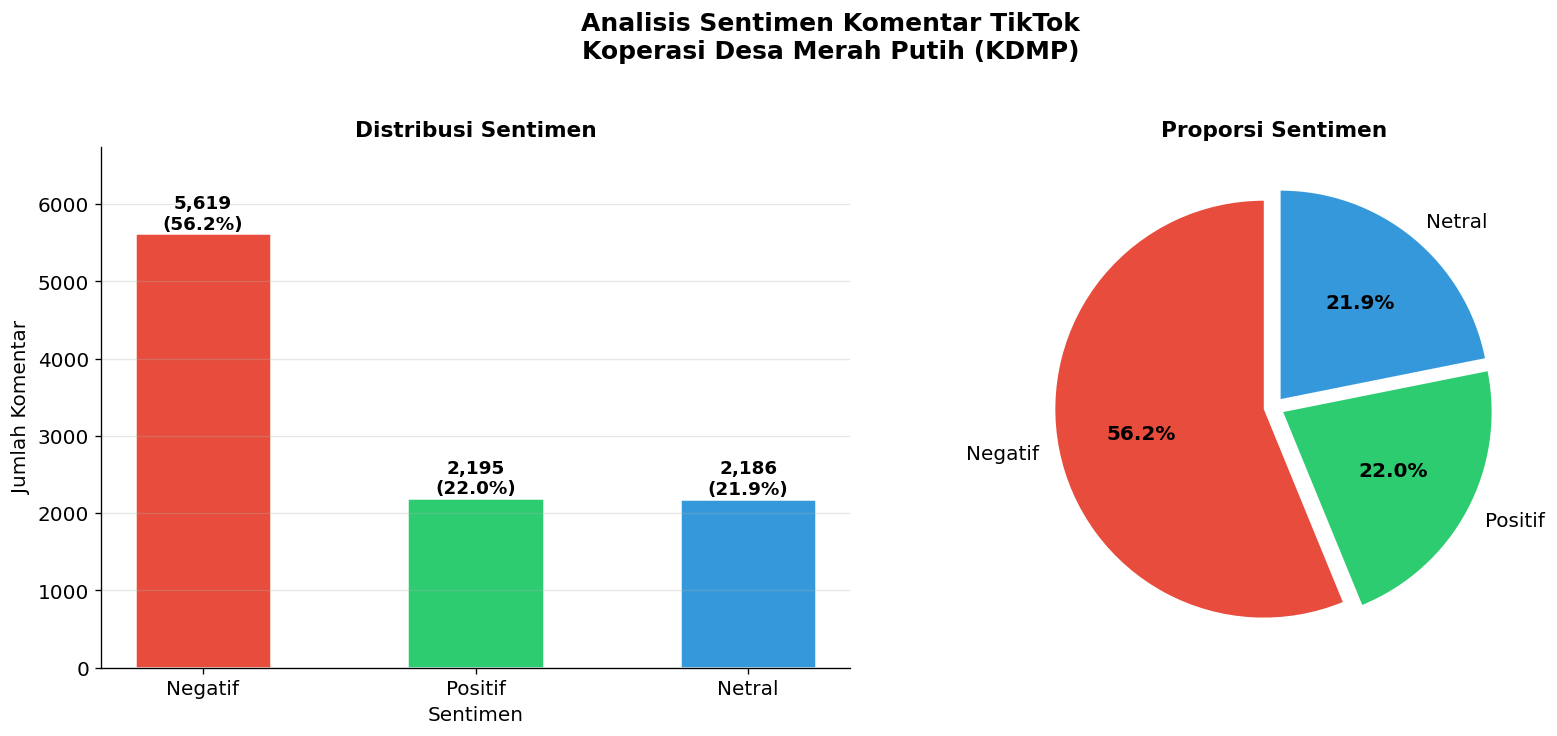

sentiment
Negatif    56.2
Positif    22.0
Netral     21.9
Name: count, dtype: float64


In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 12

COLORS = {'Positif': '#2ecc71', 'Netral': '#3498db', 'Negatif': '#e74c3c'}

sentiment_counts = df_clean['sentiment'].value_counts()
sentiment_pct    = (sentiment_counts / len(df_clean) * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Analisis Sentimen Komentar TikTok\nKoperasi Desa Merah Putih (KDMP)',
             fontsize=15, fontweight='bold', y=1.02)

# --- Bar chart ---
ax1 = axes[0]
bars = ax1.bar(sentiment_counts.index, sentiment_counts.values,
               color=[COLORS.get(s, '#95a5a6') for s in sentiment_counts.index],
               edgecolor='white', linewidth=1.5, width=0.5)
for bar, val, pct in zip(bars, sentiment_counts.values, sentiment_pct.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{val:,}\n({pct}%)', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax1.set_title('Distribusi Sentimen', fontsize=13, fontweight='bold')
ax1.set_xlabel('Sentimen')
ax1.set_ylabel('Jumlah Komentar')
ax1.set_ylim(0, max(sentiment_counts.values) * 1.2)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(axis='y', alpha=0.3)

# --- Pie chart ---
ax2 = axes[1]
wedge_colors = [COLORS.get(s, '#95a5a6') for s in sentiment_counts.index]
wedges, texts, autotexts = ax2.pie(
    sentiment_counts.values,
    labels=sentiment_counts.index,
    autopct='%1.1f%%',
    colors=wedge_colors,
    startangle=90,
    explode=[0.05]*len(sentiment_counts),
    textprops={'fontsize': 12}
)
for autotext in autotexts:
    autotext.set_fontweight('bold')
ax2.set_title('Proporsi Sentimen', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('sentiment_distribution.png', bbox_inches='tight')
plt.show()
print(sentiment_pct)

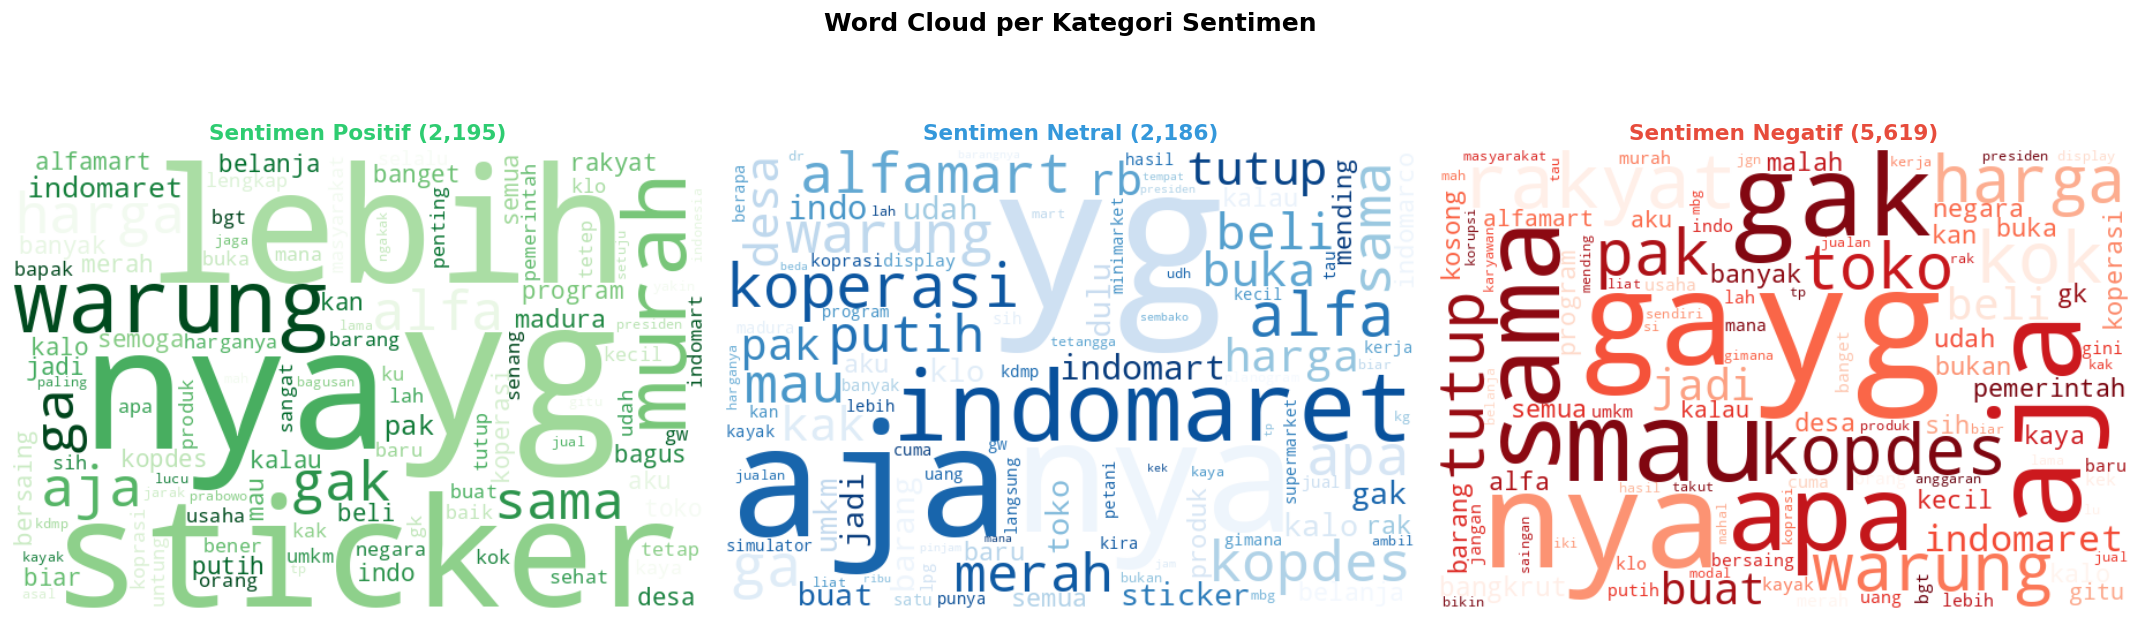

In [15]:
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Word Cloud per Kategori Sentimen', fontsize=15, fontweight='bold')

for idx, (sent, color) in enumerate(COLORS.items()):
    texts_sent = df_clean[df_clean['sentiment'] == sent]['text_clean'].dropna()
    all_words = ' '.join(texts_sent.tolist())

    if all_words.strip():
        wc = WordCloud(
            width=600, height=400,
            background_color='white',
            colormap='Greens' if sent=='Positif' else ('Blues' if sent=='Netral' else 'Reds'),
            max_words=100,
            collocations=False
        ).generate(all_words)
        axes[idx].imshow(wc, interpolation='bilinear')

    axes[idx].set_title(f'Sentimen {sent} ({len(texts_sent):,})',
                        fontsize=13, fontweight='bold', color=color)
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('wordcloud_sentiment.png', bbox_inches='tight')
plt.show()

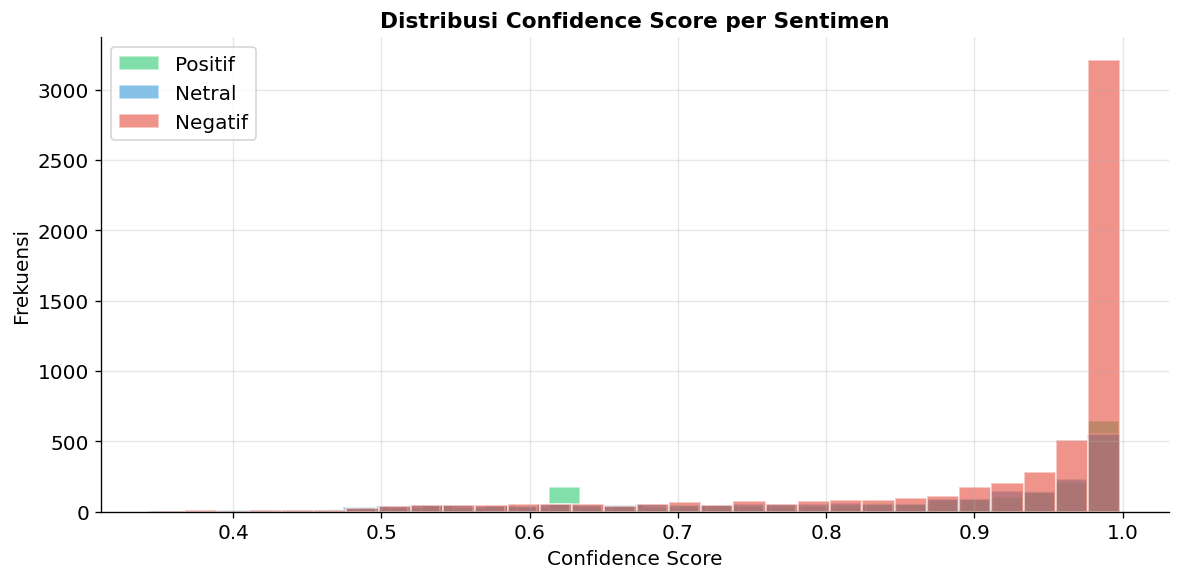

In [16]:
# Distribusi confidence score
fig, ax = plt.subplots(figsize=(10, 5))
for sent, color in COLORS.items():
    data = df_clean[df_clean['sentiment'] == sent]['sentiment_score']
    ax.hist(data, bins=30, alpha=0.6, label=sent, color=color, edgecolor='white')

ax.set_title('Distribusi Confidence Score per Sentimen', fontsize=13, fontweight='bold')
ax.set_xlabel('Confidence Score')
ax.set_ylabel('Frekuensi')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('confidence_distribution.png', bbox_inches='tight')
plt.show()

## 📋 8. Contoh Komentar per Sentimen

In [17]:
for sent in ['Positif', 'Negatif', 'Netral']:
    print(f"\n{'='*60}")
    print(f"🔹 Contoh Komentar {sent.upper()} (confidence > 0.85):")
    print('='*60)

    sample = df_clean[
        (df_clean['sentiment'] == sent) &
        (df_clean['sentiment_score'] > 0.85)
    ][TEXT_COL].dropna().sample(min(5, len(df_clean[df_clean['sentiment']==sent])), random_state=42)

    for i, text in enumerate(sample.values, 1):
        print(f"{i}. {text[:200]}")


🔹 Contoh Komentar POSITIF (confidence > 0.85):
1. Alhamdulillah Gas 16k. Belanjaa ahhhh..
2. Ini yg mau bersaing dg indomaret dan alfamart? Wkwkwkk
3. kalo bisa sediakan juga outfit murah murche kaka
4. ringan amat tuh kalau ngomong😂
5. terbaik presiden q... semoga bawahan bapak sampai ke masyarakat bisa menjalankan kebijakan2 adil mu pak... terbaik emang papa gemoy.. 🥰🥰🥰🥰🥰 sehat2 selalu pak.. dan semoga indonesia menjadi pusat perad

🔹 Contoh Komentar NEGATIF (confidence > 0.85):
1. merusak lapangan desa juga
2. asal nanti jgn kyk progam Oke oce aja baru bentaran Udeh tutup ujung" nya mangkrak jd lahan parkiran
3. Aset desa apa aset PENGUASA ⁉️😏
4. @🆑 ldr ta iki😭
5. kirain koprasi kayak simpan pinjam uang rupanya toko sembako

🔹 Contoh Komentar NETRAL (confidence > 0.85):
1. gas LPG ada ka harganya 18rb kalau ga salah ya. ada di salah satu VT.
2. join
3. Catat 16 rb nnt kalau lebih dr 16 rb lapor ke pak Prabowo 😂🤣
4. apa hubungannya kopdes dengan indomaret dan alfamart?
5. benerin dl

## 💾 9. Simpan Hasil

In [18]:
# Simpan hasil ke CSV
output_cols = [TEXT_COL, 'text_clean', 'sentiment', 'sentiment_score']
output_cols = [c for c in output_cols if c in df_clean.columns]

df_result = df_clean[output_cols].copy()
df_result.to_csv('hasil_sentimen_kdmp.csv', index=False, encoding='utf-8-sig')
print("✅ Hasil disimpan ke: hasil_sentimen_kdmp.csv")

# Ringkasan statistik
print("\n📊 RINGKASAN ANALISIS SENTIMEN")
print("=" * 40)
print(f"Total komentar dianalisis: {len(df_clean):,}")
print()
for sent in ['Positif', 'Netral', 'Negatif']:
    count = (df_clean['sentiment'] == sent).sum()
    pct   = count / len(df_clean) * 100
    avg_score = df_clean[df_clean['sentiment']==sent]['sentiment_score'].mean()
    print(f"  {sent:10s}: {count:5,} ({pct:5.1f}%)  avg confidence: {avg_score:.3f}")

✅ Hasil disimpan ke: hasil_sentimen_kdmp.csv

📊 RINGKASAN ANALISIS SENTIMEN
Total komentar dianalisis: 10,000

  Positif   : 2,195 ( 21.9%)  avg confidence: 0.838
  Netral    : 2,186 ( 21.9%)  avg confidence: 0.834
  Negatif   : 5,619 ( 56.2%)  avg confidence: 0.919


In [19]:
# Download hasil ke lokal (khusus Google Colab)
try:
    from google.colab import files
    files.download('hasil_sentimen_kdmp.csv')
    files.download('sentiment_distribution.png')
    files.download('wordcloud_sentiment.png')
    print("✅ File berhasil di-download!")
except ImportError:
    print("ℹ️ Bukan di Colab — file sudah tersimpan di direktori saat ini.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ File berhasil di-download!


In [21]:
import json
from google.colab import files

# Upload file ipynb dulu dari lokal
uploaded = files.upload()  # pilih file sentiment_analysis_kdmp.ipynb dari laptop

filename = list(uploaded.keys())[0]

with open(filename, 'r') as f:
    nb = json.load(f)

if 'widgets' in nb.get('metadata', {}):
    del nb['metadata']['widgets']

with open(filename, 'w') as f:
    json.dump(nb, f)

# Download ulang yang sudah bersih
files.download(filename)

Saving sentiment_analysis_kdmp.ipynb to sentiment_analysis_kdmp.ipynb


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## ✅ Selesai!

**Apa yang sudah dilakukan:**
1. ✅ Download dataset otomatis dari Kaggle  
2. ✅ Preprocessing (hapus mention, hashtag, emoji, stopwords)  
3. ✅ Prediksi sentimen dengan IndoBERT (model khusus Bahasa Indonesia)  
4. ✅ Visualisasi distribusi sentimen & word cloud  
5. ✅ Export hasil ke CSV  

**Model yang digunakan:** `mdhugol/indonesia-bert-sentiment-classification`  
Label: **Positif**, **Netral**, **Negatif**